## 项目：分析鸢尾花种类数据

### 分析目标

此数据分析报告的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异，让我们可以对不同种类鸢尾花的属性特征进行推断。

### 简介

原始数据`Iris.csv`包括两种鸢尾花，每种有 50 个样本，以及每个样本的一些属性，包括萼片的长度和宽度、花瓣的长度和宽度。

`Iris.csv`每列的含义如下：
- Id：样本的ID。
- SepalLengthCm：萼片的长度（单位为厘米）。
- SepalWidthCm：萼片的宽度（单位为厘米）。
- PetalLengthCm：花瓣的长度（单位为厘米）。
- PetalWidthCm：花瓣的宽度（单位为厘米）。
- Species：鸢尾花种类。

### 读取数据

导入数据分析所需要的库，并通过Pandas的read_csv函数，将原始数据文件Iris.csv里的数据内容，解析为DataFrame并赋值给变量original_data。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("Iris.csv")
original_data.head()

,Id,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


### 评估和清理数据

在这一部分中，我们将对在上一部分建立的original_dataDataFrame所包含的数据进行评估和清理。

主要从两个方面进行：结构和内容，即整齐度和干净度。

数据的结构性问题指不符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”这三个标准；数据的内容性问题包括存在丢失数据、重复数据、无效数据等。

为了区分开经过清理的数据和原始的数据，我们创建新的变量cleaned_data，让它为original_data复制出的副本。我们之后的清理步骤都将被运用在cleaned_data上。

In [3]:
cleaned_data = original_data.copy()

#### 数据整齐度

In [4]:
cleaned_data.head(10)

,Id,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


**评估结果**：从头部的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

#### 数据干净度

In [5]:
# 接下来通过info，对数据内容进行大致了解。
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            150 non-null    int64  
 1   Sepal.Length  150 non-null    float64
 2   Sepal.Width   150 non-null    float64
 3   Petal.Length  150 non-null    float64
 4   Petal.Width   150 non-null    float64
 5   Species       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


从输出结果来看，cleaned_data数据共有100条观察值，不存在缺失值。

Id表示样本ID，数据类型不应为数字，应为字符串，所以需要进行数据格式转换。

In [6]:
cleaned_data["Id"] = cleaned_data["Id"].astype("str")
cleaned_data["Id"]

0        1
1        2
2        3
3        4
4        5
      ... 
145    146
146    147
147    148
148    149
149    150
Name: Id, Length: 150, dtype: str

##### **处理缺失数据**

从info方法的输出结果来看，cleaned_data不存在缺失值，因此不需要对缺失数据进行处理。

##### **处理重复数据**

In [10]:
cleaned_data["Id"].duplicated().sum()

np.int64(0)

输出结果为0，说明不存在重复值。

##### **处理不一致数据**

不一致数据可能存在于Species变量中，我们要查看是否存在多个不同值指代同一鸢尾花种类的情况。

In [12]:
cleaned_data["Species"].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

从以上输出结果来看，Species只有两种可能的值，Iris-versicolor和Iris-setosa，不存在不一致数据。

我们可以把这列的类型转换为Category，好处是比字符串类型更节约内存空间，也能表明说值的类型有限。

In [14]:
cleaned_data["Species"] = cleaned_data["Species"].astype("category")
cleaned_data["Species"]

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: category
Categories (3, str): ['setosa', 'versicolor', 'virginica']

##### **处理无效或错误数据**

In [15]:
cleaned_data.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


从以上统计信息来看，cleaned_data里不存在脱离现实意义的数值。

### 整理数据

对数据的整理，与分析方向紧密相关。此次数据分析目标是，基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异。

那么我们可以对数据基于Species列，先把各个鸢尾花种类样本数据筛选出来。

In [19]:
setosa = cleaned_data.query('Species == "setosa"')
setosa.head()

,Id,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [20]:
len(setosa)

50

In [21]:
versicolor = cleaned_data.query('Species == "versicolor"')
versicolor.head()

,Id,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,51,7.0,3.2,4.7,1.4,versicolor
51,52,6.4,3.2,4.5,1.5,versicolor
52,53,6.9,3.1,4.9,1.5,versicolor
53,54,5.5,2.3,4.0,1.3,versicolor
54,55,6.5,2.8,4.6,1.5,versicolor


In [22]:
len(versicolor)

50

### 探索数据

在着手推断统计学分析之前，我们可以先借助数据可视化，探索Setosa和Versicolor这两种鸢尾花的变量特点。

可视化探索可以帮我们对数据有一个更直观的理解，比如了解数据的分布、发现变量之间的关系，等等，从而为后续的进一步分析提供方向。

针对数值，我们可以直接绘制成对图，利用其中的密度图查看不同变量的分布，以及利用散点图了解变量之间的关系。

并且，由于此次分析目的是了解不同种类鸢尾花的属性特征是否存在差异，我们可以利用颜色对图表上不种类类的样本进行分类。

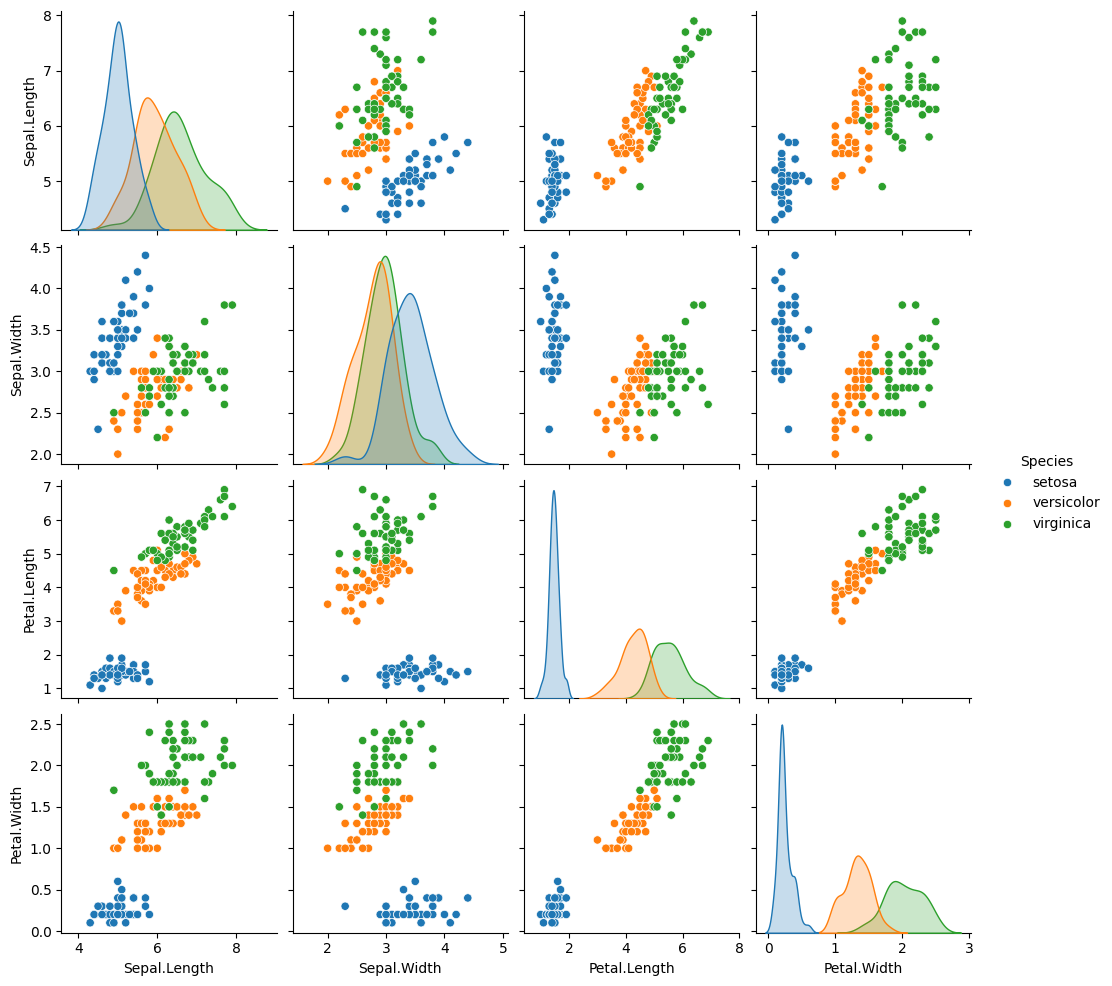

In [23]:
sns.pairplot(cleaned_data, hue="Species")
plt.show()

从以上可以看出，Setosa和Versicolor样本的花瓣长度以及花瓣宽度的分布存在明显数值上的不同，已经可以猜测假设检验的结果是，两种鸢尾花的花瓣长度与宽度有统计显著性差异。

萼片的长度和宽度在分布上存在重叠，暂时无法仅通过图表下结论，需要进行假设检验，来推断总体的萼片长度和宽度之间是否有差异。

### 分析数据

我们将利用假设检验，依次检验Setosa和Versicolor这两种鸢尾花在萼片、花瓣的长度和宽度平均值方面，是否存在统计显著性差异。

由于我们只有样本数据，不知道总体的标准差，加上两组样本数各为50，样本数量不大，因此进行t检验，而不是z检验。假设此数据集样本符合t检验的两个前提：样本为随机抽样，总体呈正态分布。

我们先引入t检验所需要的模块。

In [25]:
from scipy.stats import ttest_ind

#### **分析萼片长度**

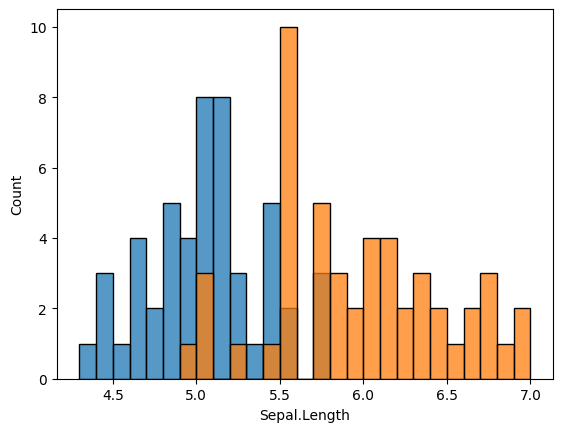

In [27]:
# 查看各个样本的萼片长度直方图长什么样，去对分布有一个大致的了解
sns.histplot(setosa['Sepal.Length'], binwidth=0.1)
sns.histplot(versicolor['Sepal.Length'], binwidth=0.1)
plt.show()

**建立假设**

$H_0$：Setosa鸢尾花和Versicolor鸢尾花萼片长度的平均值不存在显著区别。(原假设)

$H_1$：Setosa鸢尾花和Versicolor鸢尾花萼片长度的平均值存在显著区别。（备择假设）

**确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更长，所以是双尾检验。

**确定显著水平**

我们将选择0.05作为显著水平。

**计算t值和p值**

In [29]:
t_stat, p_value = ttest_ind(setosa["Sepal.Length"], versicolor['Sepal.Length'])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：-10.52098626754911
p值：8.98523503748713e-18


**验证**

In [30]:
# 显著水平为0.05（显著水平一般用alpha字母表示）
alpha = 0.05

# 比较计算出的p值和显著水平，打印是否有显著差异的结论
if p_value < alpha:
    print('两组数据有显著差异')
else:
    print('两组数据无显著差异')

两组数据有显著差异


**结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花萼片长度的平均值存在显著区别。

#### **分析萼片宽度**

Setosa 和 Versicolor 萼片宽度的分布如下。

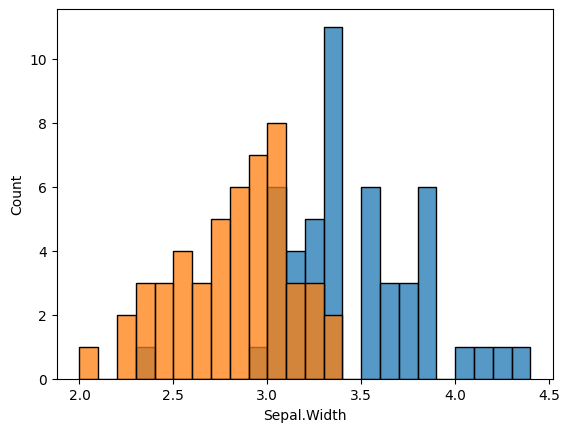

In [33]:
sns.histplot(setosa['Sepal.Width'], binwidth=0.1)
sns.histplot(versicolor['Sepal.Width'], binwidth=0.1)
plt.show()

**建立假设**

$H_0$：Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值不存在显著区别。(原假设)

$H_1$：Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值存在显著区别。（备择假设）

**确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更宽，所以是双尾检验。

**确定显著水平**

我们将选择0.05作为显著水平。

**计算t值和p值**

In [34]:
t_stat, p_value = ttest_ind(setosa["Sepal.Width"], versicolor["Sepal.Width"])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：9.454975848128596
p值：1.845259945476927e-15


**验证**

In [35]:
# 显著水平为0.05（显著水平一般用alpha字母表示）
alpha = 0.05

# 比较计算出的p值和显著水平，打印是否有显著差异的结论
if p_value < alpha:
    print('两组数据有显著差异')
else:
    print('两组数据无显著差异')

两组数据有显著差异


**结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值存在显著区别。

#### **分析花瓣长度**

Setosa 和 Versicolor 花瓣长度的分布如下。

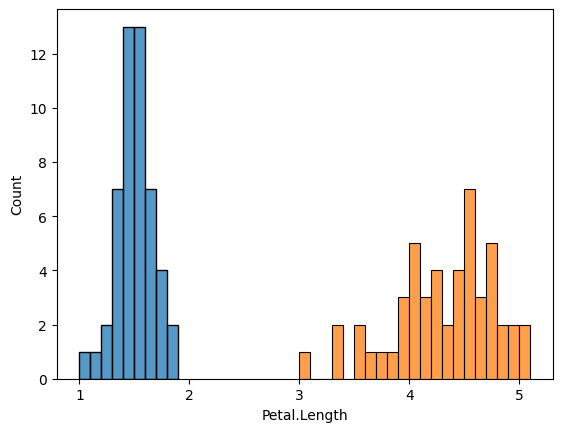

In [36]:
sns.histplot(setosa['Petal.Length'], binwidth=0.1)
sns.histplot(versicolor['Petal.Length'], binwidth=0.1)
plt.show()

**建立假设**

$H_0$：Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值不存在显著区别。(原假设)

$H_1$：Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值存在显著区别。（备择假设）

**确认检验是单尾还是双尾**
  
由于我们只检验平均值是否存在差异，不在乎哪个品种的花瓣更长，所以是双尾检验。

**确定显著水平**
  
我们将选择0.05作为显著水平。

**计算t值和p值**

In [37]:
t_stat, p_value = ttest_ind(setosa["Petal.Length"], versicolor["Petal.Length"])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：-39.492719391538095
p值：5.404910513441765e-62


**验证**

In [38]:
# 显著水平为0.05（显著水平一般用alpha字母表示）
alpha = 0.05

# 比较计算出的p值和显著水平，打印是否有显著差异的结论
if p_value < alpha:
    print('两组数据有显著差异')
else:
    print('两组数据无显著差异')

两组数据有显著差异


**结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值存在显著区别。

#### **分析花瓣宽度**

Setosa 和 Versicolor 花瓣宽度的分布如下。

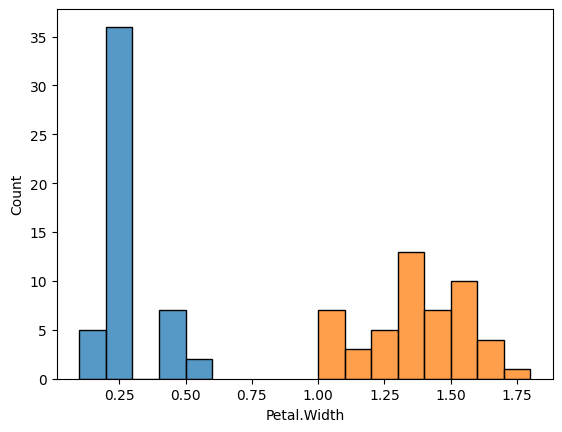

In [40]:
sns.histplot(setosa['Petal.Width'], binwidth=0.1)
sns.histplot(versicolor['Petal.Width'], binwidth=0.1)
plt.show()

**建立假设**

$H_0$：Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值不存在显著区别。(原假设)

$H_1$：Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值存在显著区别。（备择假设）

**确认检验是单尾还是双尾**
  
由于我们只检验平均值是否存在差异，不在乎哪个品种的花瓣更宽，所以是双尾检验。

**确定显著水平**
  
我们将选择0.05作为显著水平。

**计算t值和p值**

In [42]:
t_stat, p_value = ttest_ind(setosa["Petal.Width"], versicolor["Petal.Width"])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：-34.08034154357719
p值：3.831095388248147e-56


**验证**

In [43]:
# 显著水平为0.05（显著水平一般用alpha字母表示）
alpha = 0.05

# 比较计算出的p值和显著水平，打印是否有显著差异的结论
if p_value < alpha:
    print('两组数据有显著差异')
else:
    print('两组数据无显著差异')

两组数据有显著差异


**结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值存在显著区别。

### 结论

通过推论统计学的计算过程，我们发现，Setosa鸢尾花和Versicolor鸢尾花萼片、花瓣的长度和宽度平均值，均存在具有统计显著性的差异。